In [5]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     -------------------------------------- - 51.2/52.8 kB 2.6 MB/s eta 0:00:01
     ---------------------------------------- 52.8/52.8 kB 1.4 MB/s eta 0:00:00
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     -------------------------------------- 121.0/121.0 kB 6.9 MB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 61.0/61.0 kB ? eta 0:00:00
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ------ --------------------------------- 1.5/9.8 MB 31.4 MB/s eta 0:00:01
   ------ --------------------------------- 1.5/9.8 MB 16.3 MB/s eta 0:00:01
   ------ --------------------------------- 1.6/9.8 MB 11.4 MB/s eta 0:00:01
   ------ --------------------------------- 1.7/9.8 MB 8.9 MB/s eta 0:00:01
   ------- -----------------


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

print("✅ All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


✅ All libraries imported successfully!


In [7]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)        # Rows × Columns
print("\nColumn Names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

Column Names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Churn Distribution ===")
print(df['Churn'].value_counts())

=== Data Types ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pap

C:\Users\zaina\AppData\Local\Temp\ipykernel_7588\3118531910.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])


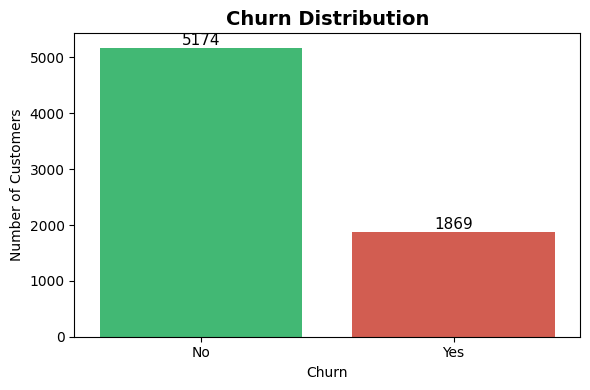

In [9]:
# How many customers churned vs stayed?
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

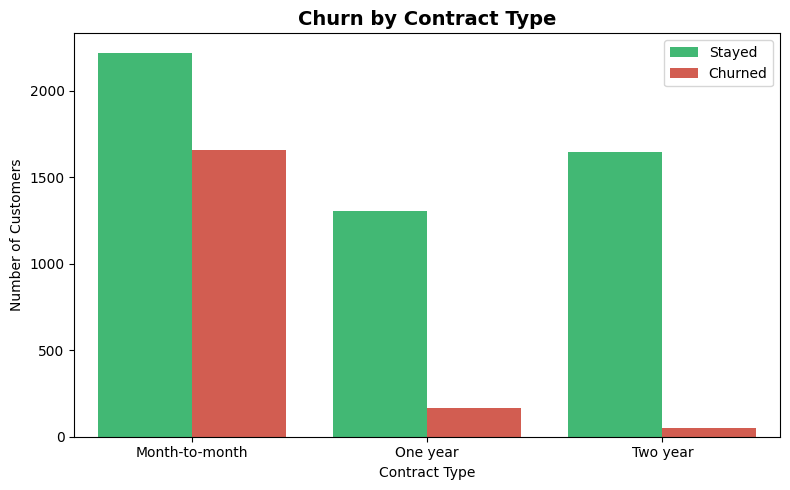

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn',
              palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(labels=['Stayed', 'Churned'])
plt.tight_layout()
plt.show()

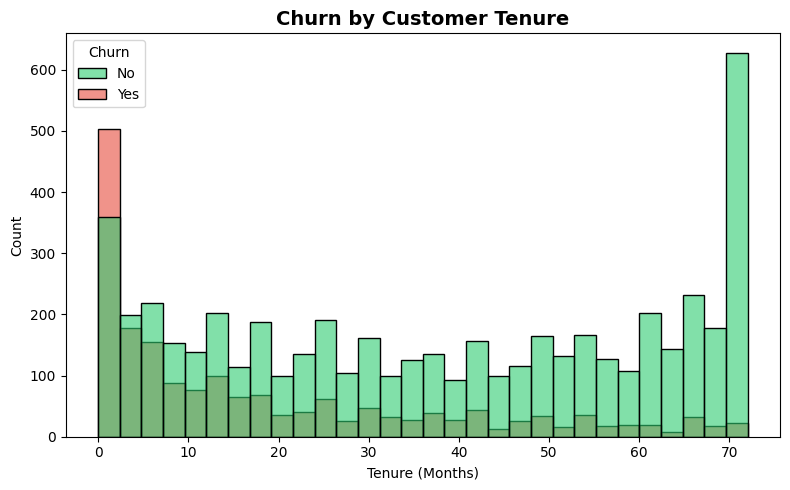

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='tenure', hue='Churn',
             bins=30, palette=['#2ecc71', '#e74c3c'], alpha=0.6)
plt.title('Churn by Customer Tenure', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\zaina\AppData\Local\Temp\ipykernel_7588\214525702.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges',


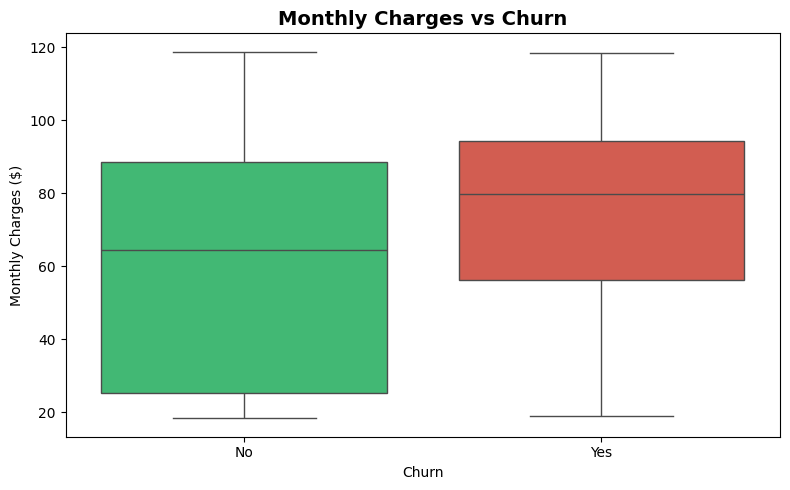

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette=['#2ecc71', '#e74c3c'])
plt.title('Monthly Charges vs Churn', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

DO THE BELOW STEP AFTER DATA CLEANING AND ENCODING 

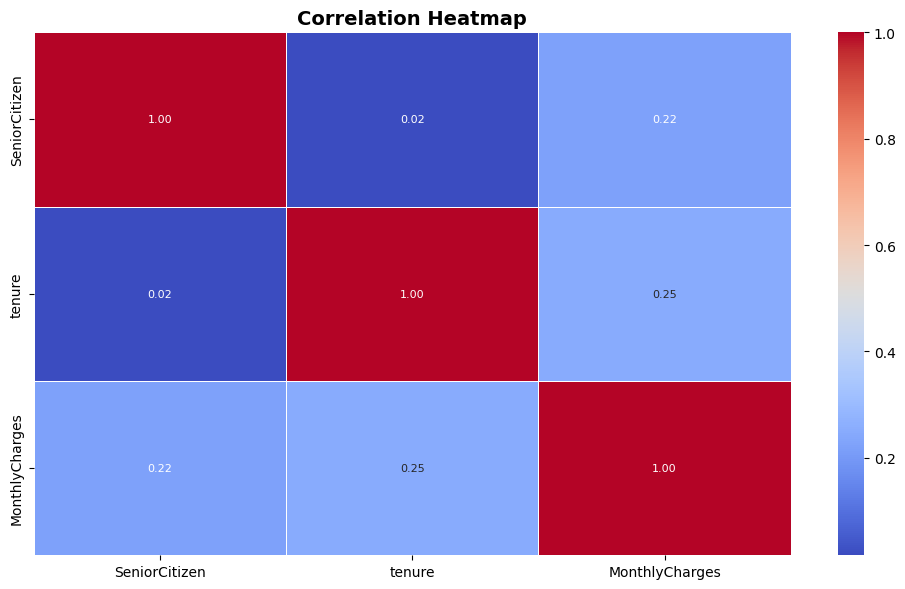

In [13]:
# Only numeric columns for correlation
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Check the problem first
print("Before fix - TotalCharges dtype:", df['TotalCharges'].dtype)
print("Sample values:", df['TotalCharges'].head())

Before fix - TotalCharges dtype: str
Sample values: 0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: str


In [16]:
# Convert TotalCharges to numeric — blank spaces become NaN (Not a Number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN values were created
print("Null values in TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

# Check which rows have NaN — let's see what they look like
print("\nRows with missing TotalCharges:")
print(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

Null values in TotalCharges after conversion: 11

Rows with missing TotalCharges:
      tenure  MonthlyCharges  TotalCharges Churn
488        0           52.55           NaN    No
753        0           20.25           NaN    No
936        0           80.85           NaN    No
1082       0           25.75           NaN    No
1340       0           56.05           NaN    No
3331       0           19.85           NaN    No
3826       0           25.35           NaN    No
4380       0           20.00           NaN    No
5218       0           19.70           NaN    No
6670       0           73.35           NaN    No
6754       0           61.90           NaN    No


In [17]:
# Drop rows where TotalCharges is NaN
df.dropna(inplace=True)

# Confirm they're gone
print("Dataset shape after dropping nulls:", df.shape)
print("Any remaining nulls?", df.isnull().sum().sum())

Dataset shape after dropping nulls: (7032, 21)
Any remaining nulls? 0


In [18]:
# CustomerID is just an identifier — no predictive value
df.drop('customerID', axis=1, inplace=True)

print("Columns remaining:", df.shape[1])
print(df.columns.tolist())

Columns remaining: 20
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [20]:
print("=== Final Shape ===")
print(df.shape)

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Any Nulls? ===")
print(df.isnull().sum().sum(), "total null values")

print("\n=== Sample of Clean Data ===")
df.head(5)

=== Final Shape ===
(7032, 20)

=== Data Types ===
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

=== Any Nulls? ===
0 total null values

=== Sample of Clean Data ===


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [21]:
# Convert Churn: "Yes" → 1, "No" → 0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Verify
print("Churn unique values:", df['Churn'].unique())
print("Churn distribution:\n", df['Churn'].value_counts())

Churn unique values: [0 1]
Churn distribution:
 Churn
0    5163
1    1869
Name: count, dtype: int64


In [22]:
# Feature 1: Average monthly spend over their lifetime
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

# Feature 2: Flag high-risk customers (new + expensive)
df['HighRisk'] = ((df['tenure'] < 6) & (df['MonthlyCharges'] > 65)).astype(int)

# Feature 3: Number of services the customer has subscribed to
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['TotalServices'] = df[service_cols].apply(lambda x: (x == 'Yes').sum(), axis=1)

# Preview the new features
print(df[['tenure', 'MonthlyCharges', 'TotalCharges',
          'AvgMonthlySpend', 'HighRisk', 'TotalServices']].head(5))

   tenure  MonthlyCharges  TotalCharges  AvgMonthlySpend  HighRisk  \
0       1           29.85         29.85        14.925000         0   
1      34           56.95       1889.50        53.985714         0   
2       2           53.85        108.15        36.050000         0   
3      45           42.30       1840.75        40.016304         0   
4       2           70.70        151.65        50.550000         1   

   TotalServices  
0              1  
1              3  
2              3  
3              3  
4              1  


In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Get all columns that are still text/object type
cat_cols = df.select_dtypes(include='object').columns
print("Columns to encode:", cat_cols.tolist())

# Loop through each text column and encode it
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    
print("\n✅ Encoding complete!")
print("\nData types after encoding:")
print(df.dtypes)

Columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✅ Encoding complete!

Data types after encoding:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
AvgMonthlySpend     float64
HighRisk              int64
TotalServices         int64
dtype: object


C:\Users\zaina\AppData\Local\Temp\ipykernel_7588\4216048445.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [24]:
print("=== Shape ===")
print(df.shape)

print("\n=== Data Types (should be all numbers now) ===")
print(df.dtypes)

print("\n=== Any object columns remaining? ===")
remaining = df.select_dtypes(include='object').columns.tolist()
print(remaining if remaining else "✅ None — all columns are numeric!")

print("\n=== Preview of Final Dataset ===")
df.head(3)

=== Shape ===
(7032, 23)

=== Data Types (should be all numbers now) ===
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
AvgMonthlySpend     float64
HighRisk              int64
TotalServices         int64
dtype: object

=== Any object columns remaining? ===
✅ None — all columns are numeric!

=== Preview of Final Dataset ===


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,HighRisk,TotalServices
0,0,0,1,0,1,0,1,0,0,2,...,0,0,1,2,29.85,29.85,0,14.925000,0,1
1,1,0,0,0,34,1,0,0,2,0,...,0,1,0,3,56.95,1889.50,0,53.985714,0,3
2,1,0,0,0,2,1,0,0,2,2,...,0,0,1,3,53.85,108.15,1,36.050000,0,3


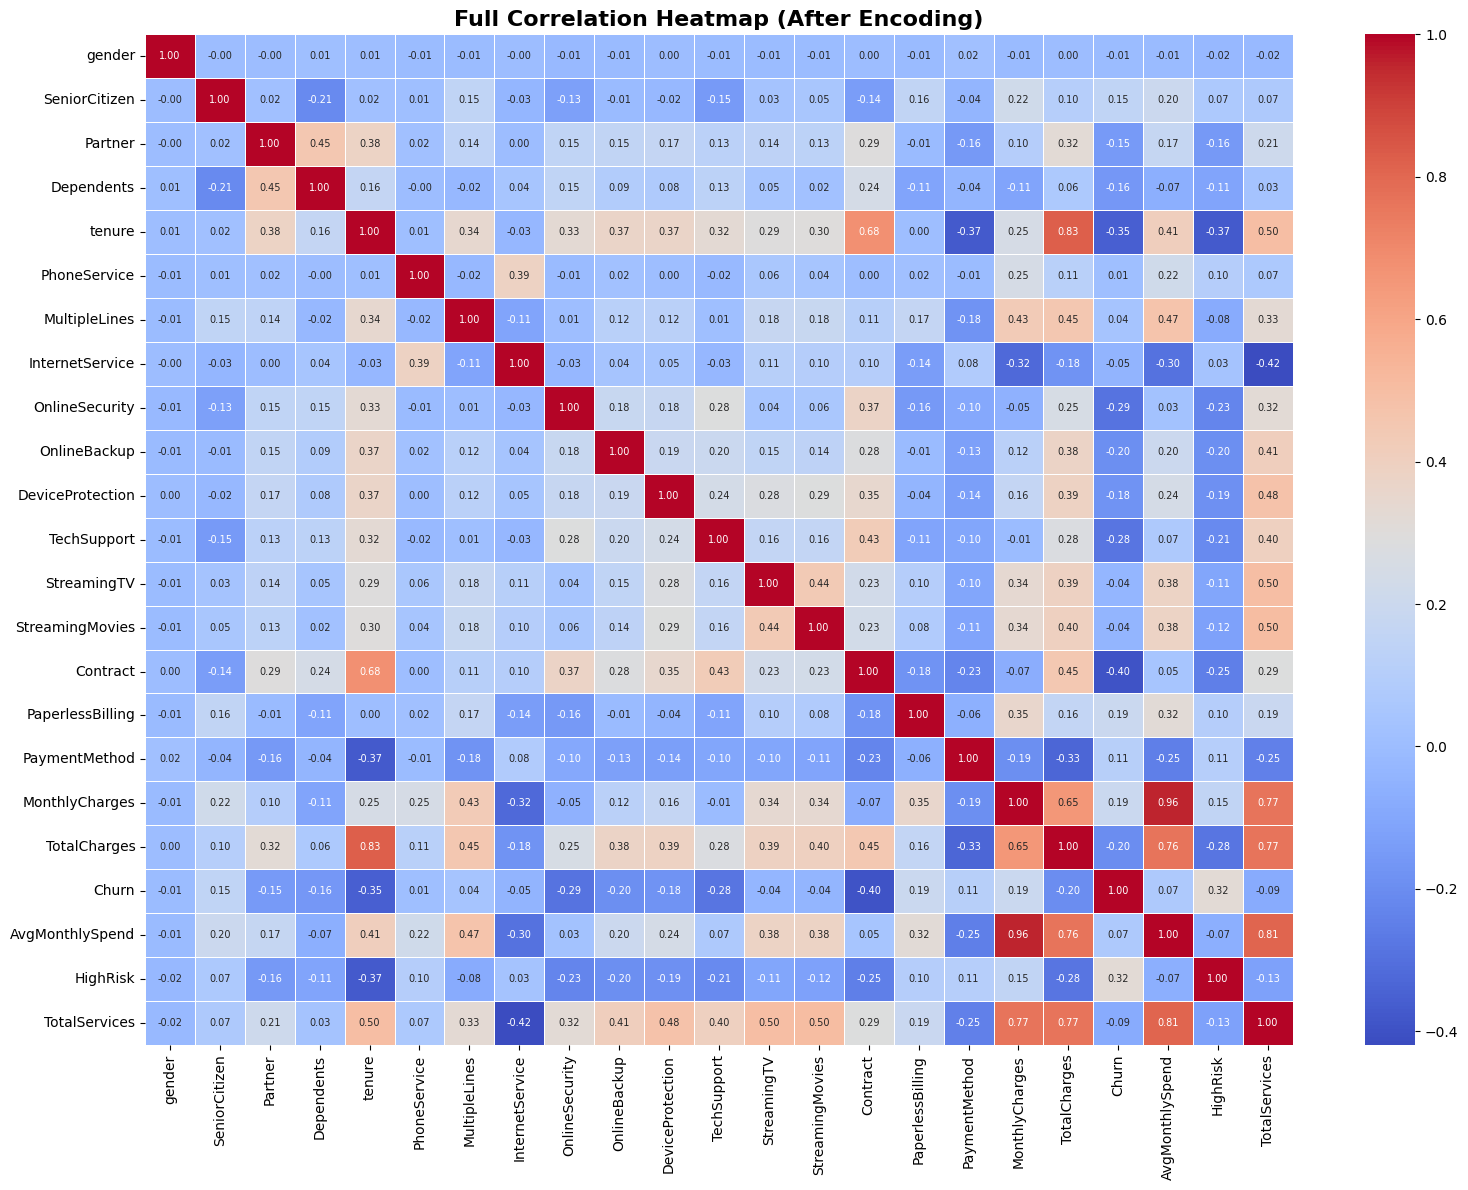


=== Top Features Correlated with Churn ===
HighRisk            0.323312
MonthlyCharges      0.192858
PaperlessBilling    0.191454
SeniorCitizen       0.150541
PaymentMethod       0.107852
AvgMonthlySpend     0.070992
MultipleLines       0.038043
PhoneService        0.011691
gender             -0.008545
StreamingTV        -0.036303
StreamingMovies    -0.038802
InternetService    -0.047097
TotalServices      -0.086173
Partner            -0.149982
Dependents         -0.163128
DeviceProtection   -0.177883
OnlineBackup       -0.195290
TotalCharges       -0.199484
TechSupport        -0.282232
OnlineSecurity     -0.289050
tenure             -0.354049
Contract           -0.396150
Name: Churn, dtype: float64


In [25]:
# NOW run the full correlation heatmap — all columns are numeric
plt.figure(figsize=(16, 12))
corr = df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Full Correlation Heatmap (After Encoding)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Most correlated features with Churn specifically
print("\n=== Top Features Correlated with Churn ===")
churn_corr = corr['Churn'].drop('Churn').sort_values(ascending=False)
print(churn_corr)

In [26]:
# X = everything the model learns FROM (input)
# y = what the model is trying to PREDICT (output)

X = df.drop('Churn', axis=1)  # All columns except Churn
y = df['Churn']               # Only the Churn column

print("X shape (features):", X.shape)
print("y shape (target):", y.shape)
print("\nFeature columns:", X.columns.tolist())

X shape (features): (7032, 22)
y shape (target): (7032,)

Feature columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'HighRisk', 'TotalServices']


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing, 80% for training
    random_state=42,     # Fixed seed — ensures same split every run
    stratify=y           # Keeps 26% churn ratio in BOTH train and test
)

print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)
print("\nChurn ratio in training set:", round(y_train.mean() * 100, 1), "%")
print("Churn ratio in test set:    ", round(y_test.mean() * 100, 1), "%")

Training set size: (5625, 22)
Testing set size:  (1407, 22)

Churn ratio in training set: 26.6 %
Churn ratio in test set:     26.6 %


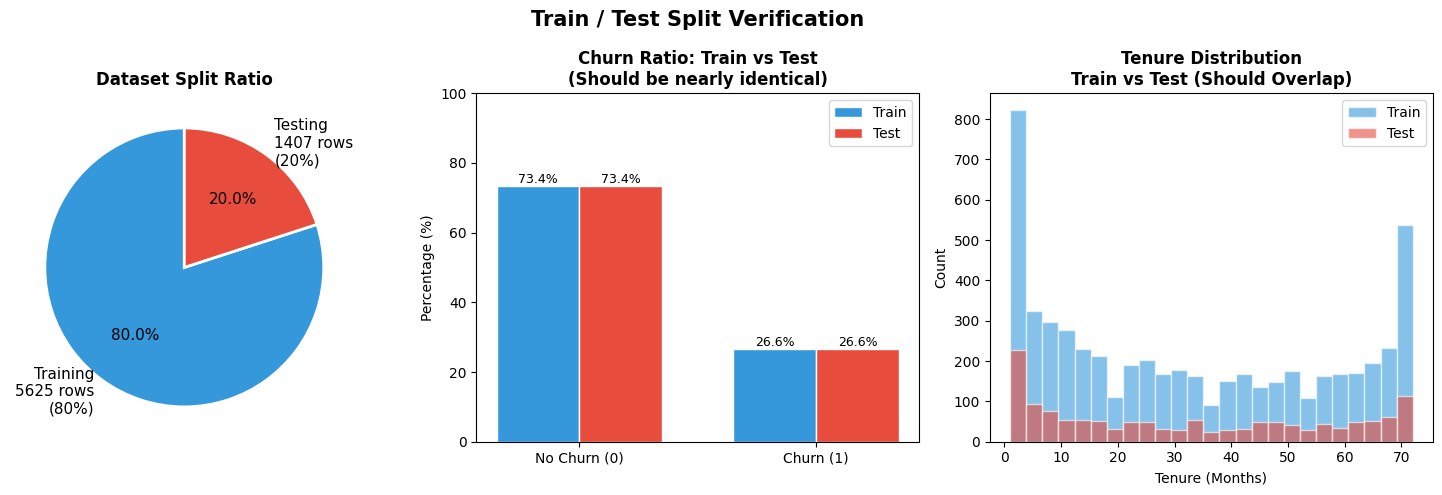

  Total samples   : 7032
  Training samples: 5625 (80.0%)
  Testing samples : 1407  (20.0%)
---------------------------------------------
  Train churn rate: 26.58%
  Test  churn rate: 26.58%
  Difference      : 0.004%  ✅ (should be < 1%)


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Train / Test Split Verification', fontsize=15, fontweight='bold')

# --- Plot 1: Split Size ---
sizes = [len(X_train), len(X_test)]
labels = [f'Training\n{len(X_train)} rows\n(80%)', f'Testing\n{len(X_test)} rows\n(20%)']
axes[0].pie(sizes, labels=labels, colors=['#3498db', '#e74c3c'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Dataset Split Ratio', fontweight='bold')

# --- Plot 2: Churn ratio in Train vs Test ---
train_churn = y_train.value_counts(normalize=True) * 100
test_churn  = y_test.value_counts(normalize=True) * 100

x = ['No Churn (0)', 'Churn (1)']
x_pos = range(len(x))
width = 0.35

axes[1].bar([p - width/2 for p in x_pos], train_churn.sort_index(),
            width=width, label='Train', color='#3498db', edgecolor='white')
axes[1].bar([p + width/2 for p in x_pos], test_churn.sort_index(),
            width=width, label='Test', color='#e74c3c', edgecolor='white')

axes[1].set_title('Churn Ratio: Train vs Test\n(Should be nearly identical)', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticks(list(x_pos))
axes[1].set_xticklabels(x)
axes[1].legend()
axes[1].set_ylim(0, 100)

for bar in axes[1].patches:
    axes[1].annotate(f'{bar.get_height():.1f}%',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontsize=9)

# --- Plot 3: Feature distribution check (tenure) ---
axes[2].hist(X_train['tenure'], bins=25, alpha=0.6,
             color='#3498db', label='Train', edgecolor='white')
axes[2].hist(X_test['tenure'],  bins=25, alpha=0.6,
             color='#e74c3c', label='Test',  edgecolor='white')
axes[2].set_title('Tenure Distribution\nTrain vs Test (Should Overlap)', fontweight='bold')
axes[2].set_xlabel('Tenure (Months)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()

# --- Printed Summary ---
print("=" * 45)
print(f"  Total samples   : {len(X_train) + len(X_test)}")
print(f"  Training samples: {len(X_train)} ({len(X_train)/(len(X_train)+len(X_test))*100:.1f}%)")
print(f"  Testing samples : {len(X_test)}  ({len(X_test)/(len(X_train)+len(X_test))*100:.1f}%)")
print("-" * 45)
print(f"  Train churn rate: {y_train.mean()*100:.2f}%")
print(f"  Test  churn rate: {y_test.mean()*100:.2f}%")
print(f"  Difference      : {abs(y_train.mean()-y_test.mean())*100:.3f}%  ✅ (should be < 1%)")
print("=" * 45)

In [35]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Use StratifiedKFold — preserves churn ratio in every fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run cross validation on all 3 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0)
}

print("=" * 55)
print(f"{'Model':<25} {'Mean AUC':>10} {'Std Dev':>10}")
print("-" * 55)

cv_results = {}
for name, model in models.items():
    # Use scaled data for LR, unscaled for tree models
    data = X_train_sc if name == 'Logistic Regression' else X_train
    scores = cross_val_score(model, data, y_train,
                             cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<25} {scores.mean():>10.3f} {scores.std():>10.4f}")

print("=" * 55)
print("\n✅ Low Std Dev (< 0.01) = model is stable and consistent")

Model                       Mean AUC    Std Dev
-------------------------------------------------------
Logistic Regression            0.848     0.0050
Random Forest                  0.829     0.0021
XGBoost                        0.827     0.0044

✅ Low Std Dev (< 0.01) = model is stable and consistent


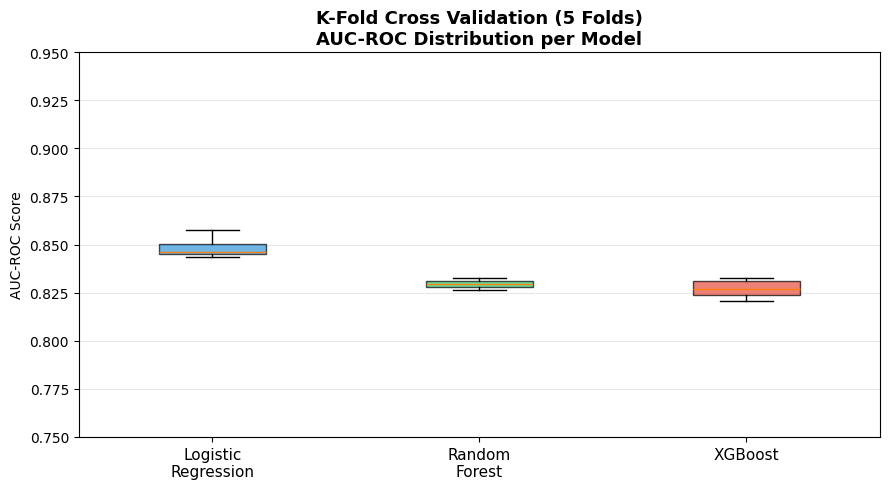

In [36]:
plt.figure(figsize=(9, 5))

colors = ['#3498db', '#2ecc71', '#e74c3c']
positions = [1, 2, 3]

bp = plt.boxplot(
    [cv_results['Logistic Regression'],
     cv_results['Random Forest'],
     cv_results['XGBoost']],
    positions=positions,
    patch_artist=True,
    widths=0.4
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.xticks(positions,
           ['Logistic\nRegression', 'Random\nForest', 'XGBoost'],
           fontsize=11)
plt.ylabel('AUC-ROC Score')
plt.title('K-Fold Cross Validation (5 Folds)\nAUC-ROC Distribution per Model',
          fontsize=13, fontweight='bold')
plt.ylim(0.75, 0.95)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data ONLY — then transform both
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("✅ Scaling complete!")
print("Sample scaled values (first row):", X_train_sc[0][:5].round(2))

✅ Scaling complete!
Sample scaled values (first row): [ 1.   -0.44  1.03  1.53  1.32]


In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)   # Uses SCALED data
lr_pred = lr.predict(X_test_sc)
lr_prob = lr.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, lr_pred) * 100, 2), "%")
print("AUC-ROC: ", round(roc_auc_score(y_test, lr_prob), 3))

=== Logistic Regression ===
Accuracy: 79.32 %
AUC-ROC:  0.837


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)    # Uses UNSCALED data — trees don't need scaling
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print("Accuracy:", round(accuracy_score(y_test, rf_pred) * 100, 2), "%")
print("AUC-ROC: ", round(roc_auc_score(y_test, rf_prob), 3))

=== Random Forest ===
Accuracy: 78.82 %
AUC-ROC:  0.819


In [31]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    verbosity=0           # Silences training logs
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print("Accuracy:", round(accuracy_score(y_test, xgb_pred) * 100, 2), "%")
print("AUC-ROC: ", round(roc_auc_score(y_test, xgb_prob), 3))

=== XGBoost ===
Accuracy: 77.61 %
AUC-ROC:  0.811


In [32]:
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy (%)': [
        round(accuracy_score(y_test, lr_pred) * 100, 2),
        round(accuracy_score(y_test, rf_pred) * 100, 2),
        round(accuracy_score(y_test, xgb_pred) * 100, 2)
    ],
    'AUC-ROC': [
        round(roc_auc_score(y_test, lr_prob), 3),
        round(roc_auc_score(y_test, rf_prob), 3),
        round(roc_auc_score(y_test, xgb_prob), 3)
    ]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy (%)  AUC-ROC
Logistic Regression         79.32    0.837
      Random Forest         78.82    0.819
            XGBoost         77.61    0.811


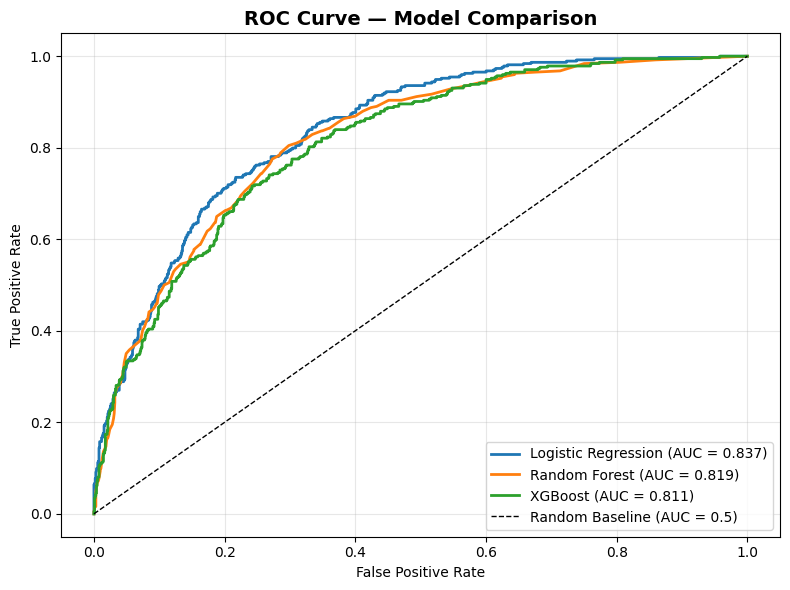

In [33]:
plt.figure(figsize=(8, 6))

# Plot ROC curve for each model
for name, prob in [('Logistic Regression', lr_prob),
                   ('Random Forest', rf_prob),
                   ('XGBoost', xgb_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = round(roc_auc_score(y_test, prob), 3)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc})', linewidth=2)

# Random baseline (a coin flip model)
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline (AUC = 0.5)', linewidth=1)

plt.title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

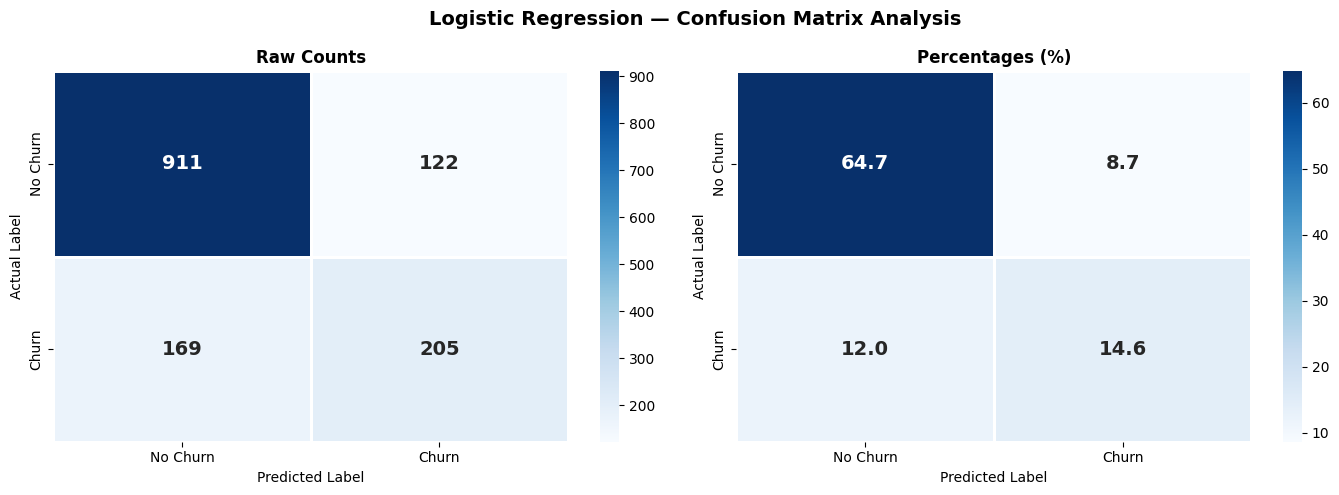

  True Negatives  (TN):   911 — correctly identified loyal customers
  False Positives (FP):   122 — loyal customers flagged as churners
  False Negatives (FN):   169 — ⚠️  missed churners (most costly!)
  True Positives  (TP):   205 — correctly caught churners
---------------------------------------------
  Precision : 62.7% — of predicted churners, how many really churned
  Recall    : 54.8% — of actual churners, how many did we catch
  F1 Score  : 58.5% — balance between precision & recall


In [43]:
#confusion matrix 
cm = confusion_matrix(y_test, lr_pred)
cm_pct = cm / cm.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logistic Regression — Confusion Matrix Analysis', fontsize=14, fontweight='bold')

# --- Left: Raw counts ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            ax=axes[0], linewidths=2,
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Raw Counts', fontweight='bold')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# --- Right: Percentages ---
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            ax=axes[1], linewidths=2,
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title('Percentages (%)', fontweight='bold')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print("=" * 45)
print(f"  True Negatives  (TN): {tn:>5} — correctly identified loyal customers")
print(f"  False Positives (FP): {fp:>5} — loyal customers flagged as churners")
print(f"  False Negatives (FN): {fn:>5} — ⚠️  missed churners (most costly!)")
print(f"  True Positives  (TP): {tp:>5} — correctly caught churners")
print("-" * 45)
print(f"  Precision : {tp/(tp+fp)*100:.1f}% — of predicted churners, how many really churned")
print(f"  Recall    : {tp/(tp+fn)*100:.1f}% — of actual churners, how many did we catch")
print(f"  F1 Score  : {2*tp/(2*tp+fp+fn)*100:.1f}% — balance between precision & recall")
print("=" * 45)

In [44]:

print("=== Full Classification Report (Logistic Regression) ===\n")
print(classification_report(y_test, lr_pred,
                             target_names=['No Churn', 'Churn']))

=== Full Classification Report (Logistic Regression) ===

              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1033
       Churn       0.63      0.55      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.72      1407
weighted avg       0.79      0.79      0.79      1407



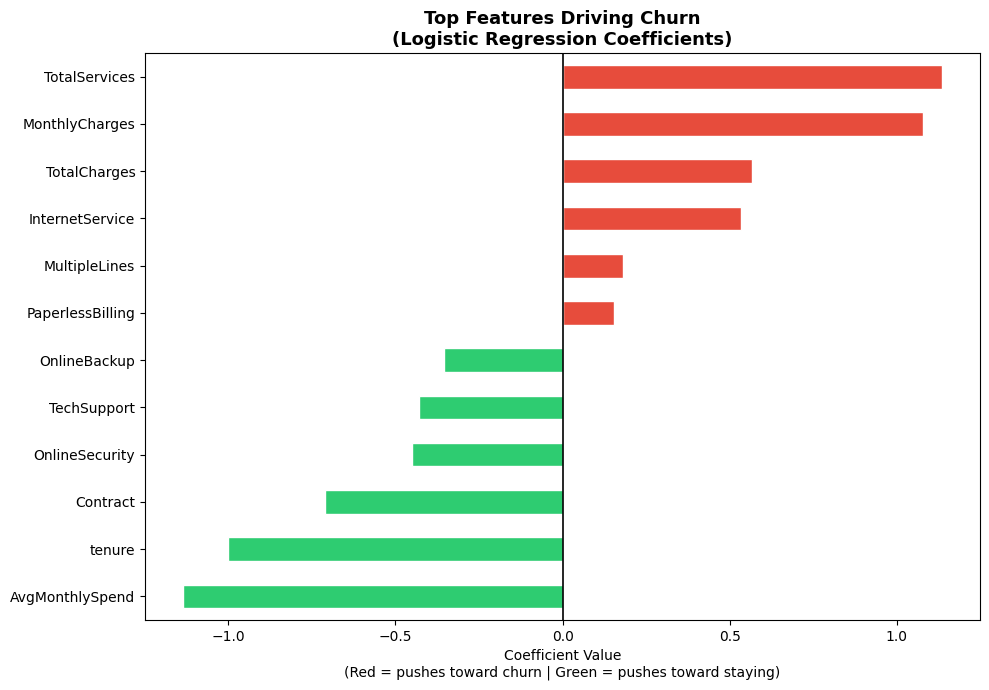


=== Top 5 Churn Drivers (Positive Coefficients) ===
TotalServices      1.135349
MonthlyCharges     1.077332
TotalCharges       0.566034
InternetService    0.532913
MultipleLines      0.181280

=== Top 5 Loyalty Drivers (Negative Coefficients) ===
AvgMonthlySpend   -1.136001
tenure            -1.000946
Contract          -0.711469
OnlineSecurity    -0.450355
TechSupport       -0.431104


In [45]:
coef = pd.Series(lr.coef_[0], index=X.columns)

# Positive = pushes toward churn, Negative = pushes away from churn
top_pos = coef.nlargest(6)   # Top churn drivers
top_neg = coef.nsmallest(6)  # Top loyalty drivers
top_features = pd.concat([top_neg, top_pos]).sort_values()

colors = ['#2ecc71' if v < 0 else '#e74c3c' for v in top_features]

plt.figure(figsize=(10, 7))
top_features.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=1.2, linestyle='-')
plt.title('Top Features Driving Churn\n(Logistic Regression Coefficients)',
          fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value\n(Red = pushes toward churn | Green = pushes toward staying)')
plt.tight_layout()
plt.savefig('visuals/2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Top 5 Churn Drivers (Positive Coefficients) ===")
print(coef.nlargest(5).to_string())
print("\n=== Top 5 Loyalty Drivers (Negative Coefficients) ===")
print(coef.nsmallest(5).to_string())

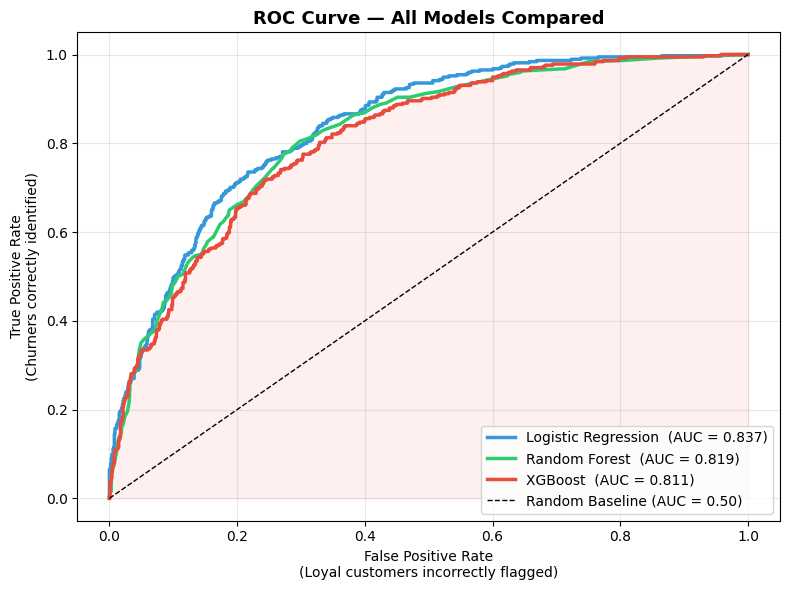

In [40]:
plt.figure(figsize=(8, 6))

model_data = [
    ('Logistic Regression', lr_prob, '#3498db'),
    ('Random Forest',       rf_prob, '#2ecc71'),
    ('XGBoost',             xgb_prob,'#e74c3c')
]

for name, prob, color in model_data:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = round(roc_auc_score(y_test, prob), 3)
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc})',
             linewidth=2.5, color=color)

plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Baseline (AUC = 0.50)')
plt.fill_between(*roc_curve(y_test, xgb_prob)[:2],
                 alpha=0.08, color='#e74c3c')

plt.title('ROC Curve — All Models Compared', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate\n(Loyal customers incorrectly flagged)')
plt.ylabel('True Positive Rate\n(Churners correctly identified)')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\zaina\AppData\Local\Temp\ipykernel_7588\3894757253.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])


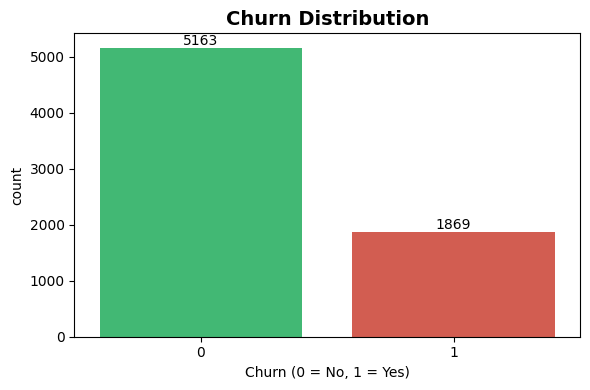

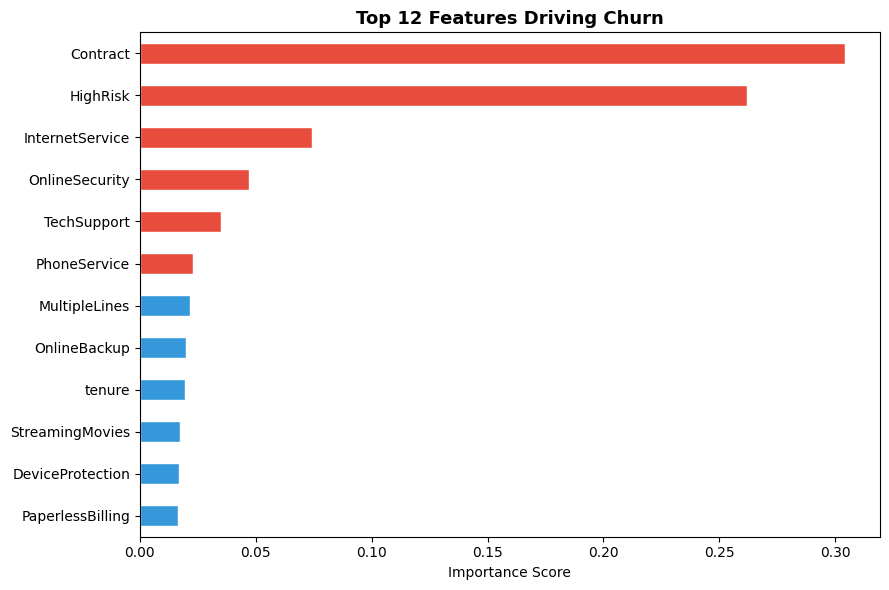

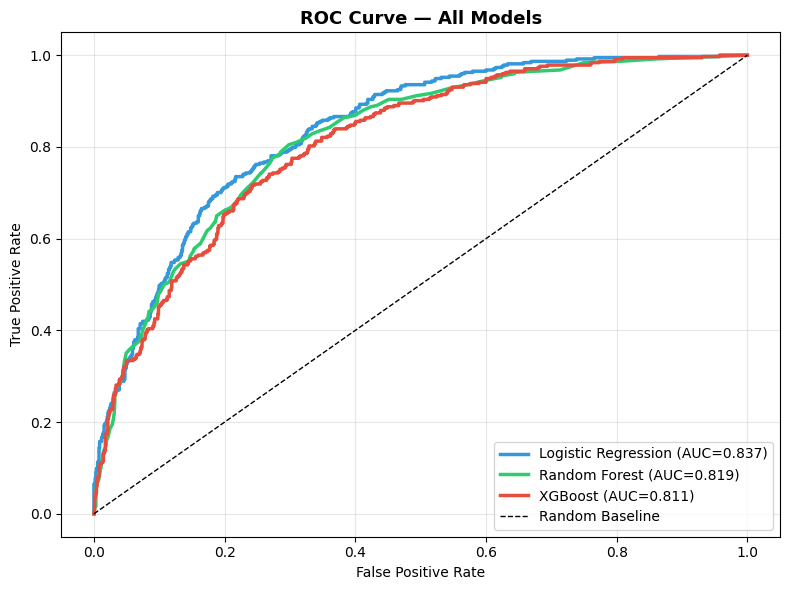

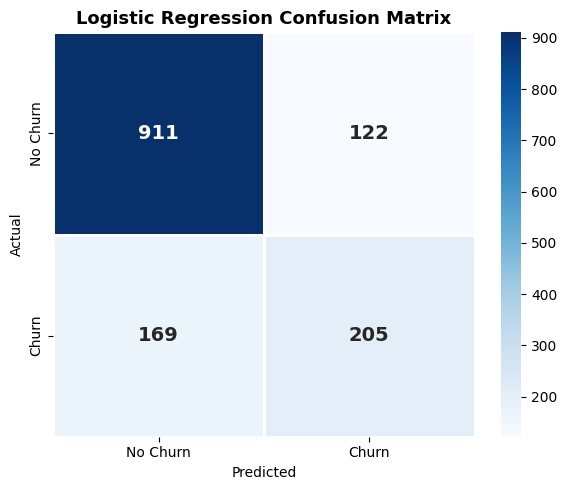

In [47]:
import os
os.makedirs('visuals', exist_ok=True)

# --- Chart 1: Churn Distribution ---
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn (0 = No, 1 = Yes)')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.savefig('visuals/1_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Chart 2: Feature Importance ---
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
top_features = feat_imp.nlargest(12).sort_values()
plt.figure(figsize=(9, 6))
colors = ['#e74c3c' if v > top_features.median() else '#3498db' for v in top_features]
top_features.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Top 12 Features Driving Churn', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('visuals/2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Chart 3: ROC Curve ---
plt.figure(figsize=(8, 6))
for name, prob, color in [('Logistic Regression', lr_prob, '#3498db'),
                           ('Random Forest', rf_prob, '#2ecc71'),
                           ('XGBoost', xgb_prob, '#e74c3c')]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = round(roc_auc_score(y_test, prob), 3)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc})', linewidth=2.5, color=color)
plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random Baseline')
plt.title('ROC Curve — All Models', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('visuals/3_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Chart 4: Confusion Matrix ---
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'],
            linewidths=2, annot_kws={'size':14,'weight':'bold'})
plt.title('Logistic Regression Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('visuals/4_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
print("=" * 55)
print("       CUSTOMER CHURN PREDICTION — FINAL SUMMARY")
print("=" * 55)
print(f"\n  Dataset   : Telco Customer Churn (IBM)")
print(f"  Rows      : {df.shape[0]:,}  |  Features: {X.shape[1]}")
print(f"  Churn Rate: {df['Churn'].mean()*100:.1f}% (class imbalance present)")

print("\n  ── Model Performance ──────────────────────────")
models_summary = {
    'Logistic Regression ✅ (best)': (lr_pred,  lr_prob),
    'Random Forest'                : (rf_pred,  rf_prob),
    'XGBoost'                      : (xgb_pred, xgb_prob)
}
for name, (pred, prob) in models_summary.items():
    acc = accuracy_score(y_test, pred) * 100
    auc = roc_auc_score(y_test, prob)
    print(f"  {name:<35} Acc: {acc:.1f}%  AUC: {auc:.3f}")

print("\n  ── Top 3 Churn Drivers ────────────────────────")
coef = pd.Series(lr.coef_[0], index=X.columns)
for i, (feat, score) in enumerate(coef.nlargest(3).items(), 1):
    print(f"  {i}. {feat:<25} coeff: {score:.4f}")

tn, fp, fn, tp = confusion_matrix(y_test, lr_pred).ravel()
print(f"\n  ── Business Impact (Logistic Regression) ──────")
print(f"  Churners correctly caught : {tp} / {tp+fn}")
print(f"  Catch rate (Recall)        : {tp/(tp+fn)*100:.1f}%")
print(f"  Missed churners (FN)       : {fn} ← most costly")
print(f"  Est. monthly revenue saved : ${tp * 65:,.0f}")
print("=" * 55)

       CUSTOMER CHURN PREDICTION — FINAL SUMMARY

  Dataset   : Telco Customer Churn (IBM)
  Rows      : 7,032  |  Features: 22
  Churn Rate: 26.6% (class imbalance present)

  ── Model Performance ──────────────────────────
  Logistic Regression ✅ (best)        Acc: 79.3%  AUC: 0.837
  Random Forest                       Acc: 78.8%  AUC: 0.819
  XGBoost                             Acc: 77.6%  AUC: 0.811

  ── Top 3 Churn Drivers ────────────────────────
  1. TotalServices             coeff: 1.1353
  2. MonthlyCharges            coeff: 1.0773
  3. TotalCharges              coeff: 0.5660

  ── Business Impact (Logistic Regression) ──────
  Churners correctly caught : 205 / 374
  Catch rate (Recall)        : 54.8%
  Missed churners (FN)       : 169 ← most costly
  Est. monthly revenue saved : $13,325
